# NUS Curriculum & Job Alignment Framework

This notebook implements a scalable, validated framework for assessing alignment between NUS degree programmes (constructed from `modules.csv`) and MyCareersFuture job advertisements.

**Objective:** Provide MOE with a credible, systematic framework for curriculum-job alignment analysis at the degree level.

**Sections:**
0. Setup
1. Data Loading & Preprocessing
2. Degree Profile Construction
3. Semantic Embedding
4. Baseline Cosine Similarity Retrieval
5. Skill Overlap Score (Hybrid Alignment)
6. Job Clustering (Scalability Layer)
7. Evaluation Framework
8. Results Summary & Interpretation

---
## Section 0: Setup

In [1]:
import os
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from bs4 import BeautifulSoup

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
REPO_ROOT      = Path('..').resolve()
DATA_DIR       = REPO_ROOT / 'data'
JOBS_DIR       = DATA_DIR  / 'MyCareersFutureData'
MODULES_CSV    = DATA_DIR  / 'modules.csv'
CACHE_DIR      = REPO_ROOT / 'notebooks' / 'cache'
EVAL_DIR       = REPO_ROOT / 'notebooks' / 'evaluation'

CACHE_DIR.mkdir(exist_ok=True)
EVAL_DIR.mkdir(exist_ok=True)

print(f'Repo root  : {REPO_ROOT}')
print(f'Jobs dir   : {JOBS_DIR}')
print(f'Modules CSV: {MODULES_CSV}')
print(f'Cache dir  : {CACHE_DIR}')

Repo root  : /Users/marcusyeo/Github/DSA4264-Text-Group-3
Jobs dir   : /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/MyCareersFutureData
Modules CSV: /Users/marcusyeo/Github/DSA4264-Text-Group-3/data/modules.csv
Cache dir  : /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache


/Users/marcusyeo/Github/DSA4264-Text-Group-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Section 1: Data Loading & Preprocessing

### 1a - NUS Modules

In [2]:
def strip_html(text: str) -> str:
    """Remove HTML tags and normalise whitespace."""
    if not isinstance(text, str) or not text.strip():
        return ''
    soup = BeautifulSoup(text, 'html.parser')
    clean = soup.get_text(separator=' ')
    return re.sub(r'\s+', ' ', clean).strip()

modules_raw = pd.read_csv(MODULES_CSV)
print(f'Raw modules shape: {modules_raw.shape}')
print(f'Columns: {list(modules_raw.columns)}')
modules_raw.head(3)

Raw modules shape: (7015, 14)
Columns: ['moduleCode', 'title', 'acadYear', 'faculty', 'department', 'moduleCredit', 'description', 'additionalInformation', 'workload', 'gradingBasisDescription', 'preclusion', 'prerequisite', 'corequisite', 'semestersOffered']


,moduleCode,title,acadYear,faculty,department,moduleCredit,description,additionalInformation,workload,gradingBasisDescription,preclusion,prerequisite,corequisite,semestersOffered
0,ABM5001,Leadership in Biomedicine,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,Leadership is fundamental to the success of in...,NaN,3/0/0/4/3,Graded,NaN,NaN,NaN,2
1,ABM5002,Advanced Biostatistics for Research,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,This course is served as a concept-based intro...,NaN,1.5/0.5/0/0/3,Graded,NaN,NaN,NaN,2
2,ABM5003,Biomedical Innovation & Enterprise,2024/2025,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,This course will furnish students with a thoro...,NaN,1.5/1.5/0/3/4,Graded,NaN,NaN,NaN,1


In [3]:
def extract_level(code: str) -> int:
    """Return the numeric level of a module code (e.g. CS1010 → 1, CS5XXX → 5)."""
    digits = re.search(r'(\d)', str(code))
    return int(digits.group(1)) if digits else 9

modules = modules_raw.copy()

# Clean descriptions
modules['description_clean'] = modules['description'].apply(strip_html)
modules['module_text'] = (
    modules['title'].fillna('') + '. ' + modules['description_clean']
).str.strip('. ')

# Mark undergrad vs postgrad
modules['level'] = modules['moduleCode'].apply(extract_level)
modules['is_undergrad'] = modules['level'].between(1, 4)

# Drop rows with no usable description
modules_clean = modules[modules['description_clean'].str.len() > 20].copy()

print(f'Total modules with descriptions: {len(modules_clean):,}')
print(f'  Undergrad (level 1–4): {modules_clean["is_undergrad"].sum():,}')
print(f'  Postgrad  (level 5+) : {(~modules_clean["is_undergrad"]).sum():,}')
print(f'Faculties : {modules_clean["faculty"].nunique()}')
print(f'Departments: {modules_clean["department"].nunique()}')
modules_clean[['moduleCode','title','faculty','department','moduleCredit','is_undergrad']].head(5)

Total modules with descriptions: 6,730
  Undergrad (level 1–4): 4,032
  Postgrad  (level 5+) : 2,698
Faculties : 24
Departments: 86


,moduleCode,title,faculty,department,moduleCredit,is_undergrad
0,ABM5001,Leadership in Biomedicine,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,False
1,ABM5002,Advanced Biostatistics for Research,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,2.0,False
2,ABM5003,Biomedical Innovation & Enterprise,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,False
3,ABM5004,Capstone Project,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,8.0,False
4,ABM5101,Applied Immunology,Yong Loo Lin Sch of Medicine,NUS Medicine Dean's Office,4.0,False


In [4]:
# Coverage: modules with descriptions per department
dept_coverage = (
    modules_clean[modules_clean['is_undergrad']]
    .groupby('department')
    .size()
    .reset_index(name='n_modules')
    .sort_values('n_modules', ascending=False)
)

sufficient = (dept_coverage['n_modules'] >= 5).sum()
print(f'Departments with ≥5 undergrad modules: {sufficient} / {len(dept_coverage)}')
dept_coverage.head(15)

Departments with ≥5 undergrad modules: 71 / 75


,department,n_modules
74,Yale-NUS College,244
73,YSTCM Dean's Office,240
62,SCALE Dean's Office,174
46,NUS College Dean's Office,162
30,FoL Dean's Office,151
7,Biological Sciences,120
56,Political Science,118
43,Mathematics,117
57,Psychology,110
13,Centre for Language Studies,107


### 1b - MyCareersFuture Job Ads

In [5]:
def parse_job_file(path: Path) -> dict | None:
    """Parse a single MCF JSON file into a flat record."""
    try:
        with open(path, 'r', encoding='utf-8') as f:
            d = json.load(f)
    except Exception:
        return None

    meta = d.get('metadata', {})
    salary = d.get('salary', {})
    sal_type = (salary.get('type') or {}).get('salaryType', '')

    skills_raw = d.get('skills', []) or []
    skills_list = [s['skill'] for s in skills_raw if isinstance(s, dict) and s.get('skill')]

    cats = d.get('categories', []) or []
    categories_list = [c['category'] for c in cats if isinstance(c, dict) and c.get('category')]

    pos = d.get('positionLevels', []) or []
    position_levels = [p['position'] for p in pos if isinstance(p, dict) and p.get('position')]

    emp_types = d.get('employmentTypes', []) or []
    employment_types = [e['employmentType'] for e in emp_types if isinstance(e, dict)]

    return {
        'job_id'           : meta.get('jobPostId', path.stem),
        'title'            : d.get('title', ''),
        'description_raw'  : d.get('description', '') or '',
        'skills'           : skills_list,
        'skills_str'       : ', '.join(skills_list),
        'categories'       : categories_list,
        'categories_str'   : ', '.join(categories_list),
        'position_levels'  : position_levels,
        'employment_types' : employment_types,
        'ssoc_code'        : d.get('ssocCode', ''),
        'salary_min'       : (salary.get('minimum') or np.nan),
        'salary_max'       : (salary.get('maximum') or np.nan),
        'salary_type'      : sal_type,
        'company'          : (d.get('postedCompany') or {}).get('name', ''),
        'posted_date'      : meta.get('newPostingDate', ''),
        'expiry_date'      : meta.get('expiryDate', ''),
    }

job_files = list(JOBS_DIR.glob('*.json'))
print(f'Found {len(job_files):,} JSON job files')

Found 22,720 JSON job files


In [8]:
JOBS_CACHE = CACHE_DIR / 'jobs_raw.parquet'

if JOBS_CACHE.exists():
    print('Loading job ads from cache...')
    jobs_raw = pd.read_parquet(JOBS_CACHE)
else:
    print('Parsing job ad JSON files...')
    records = []
    for p in tqdm(job_files, desc='Loading jobs'):
        rec = parse_job_file(p)
        if rec:
            records.append(rec)
    jobs_raw = pd.DataFrame(records)
    jobs_raw.to_parquet(JOBS_CACHE, index=False)
    print(f'Cached to {JOBS_CACHE}')

print(f'Jobs loaded: {len(jobs_raw):,}')
jobs_raw.head(3)

Loading job ads from cache...
Jobs loaded: 22,720


,job_id,title,description_raw,skills,skills_str,categories,categories_str,position_levels,employment_types,ssoc_code,salary_min,salary_max,salary_type,company,posted_date,expiry_date
0,MCF-2026-0180015,Outdoor Sales Engineer (Own Car) | Petrochemic...,<ul><li><p><strong>Role: Outdoor Sales Enginee...,"[Project Bidding, Technical Demonstrations, Sh...","Project Bidding, Technical Demonstrations, Shi...","[Engineering, Manufacturing, Marketing / Publi...","Engineering, Manufacturing, Marketing / Public...",[Executive],"[Permanent, Full Time]",24331,3000,6000,Monthly,THE SUPREME HR ADVISORY PTE. LTD.,2026-01-29,2026-02-28
1,MCF-2026-0182028,IT Administrator (Coding) @ Changi (1 Year Ren...,<p><u><strong>Job Details:</strong></u></p><ul...,"[Outlook, Microsoft PowerPoint, Microsoft Offi...","Outlook, Microsoft PowerPoint, Microsoft Offic...","[Admin / Secretarial, Information Technology]","Admin / Secretarial, Information Technology",[Senior Executive],"[Contract, Full Time]",13304,4500,5900,Monthly,RMA CONTRACTS PTE. LTD.,2026-01-29,2026-02-19
2,MCF-2025-1964969,Outsourced Finance Executive,<p><u><strong>Job Description</strong></u></p>...,"[Accounts Payable, Microsoft Office, Analytica...","Accounts Payable, Microsoft Office, Analytical...","[Accounting / Auditing / Taxation, Banking and...","Accounting / Auditing / Taxation, Banking and ...",[Executive],[Full Time],43129,3000,4000,Monthly,RT ADVISORY PTE. LTD.,2026-01-27,2026-02-26


In [9]:
# Clean job descriptions
jobs = jobs_raw.copy()
jobs['description_clean'] = jobs['description_raw'].apply(strip_html)
jobs['job_text'] = (
    jobs['title'].fillna('') + '. ' + jobs['description_clean']
).str.strip('. ')

# Drop rows with no usable description (< 30 chars)
before = len(jobs)
jobs = jobs[jobs['description_clean'].str.len() > 30].drop_duplicates('job_id').copy()
print(f'Jobs after description filter & dedup: {len(jobs):,} (dropped {before - len(jobs):,})')

# Parse skills/categories lists back (parquet stores them as objects)
for col in ['skills', 'categories', 'position_levels', 'employment_types']:
    if jobs[col].dtype == object and isinstance(jobs[col].iloc[0], str):
        import ast
        jobs[col] = jobs[col].apply(ast.literal_eval)

# Summary stats
print(f'Jobs with at least one skill tag: {jobs["skills"].apply(len).gt(0).sum():,}')
print(f'Unique categories: {set(c for cats in jobs["categories"] for c in cats)}')

Jobs after description filter & dedup: 22,720 (dropped 0)
Jobs with at least one skill tag: 22,720
Unique categories: {'Repair and Maintenance', 'Social Services', 'Events / Promotions', 'Security and Investigation', 'Consulting', 'Entertainment', 'Purchasing / Merchandising', 'Personal Care / Beauty', 'Human Resources', 'Sales / Retail', 'Marketing / Public Relations', 'Healthcare / Pharmaceutical', 'Others', 'Hospitality', 'Telecommunications', 'F&B', 'Risk Management', 'General Work', 'Manufacturing', 'Medical / Therapy Services', 'Real Estate / Property Management', 'Environment / Health', 'Insurance', 'Information Technology', 'Professional Services', 'Education and Training', 'Banking and Finance', 'Design', 'Travel / Tourism', 'Building and Construction', 'General Management', 'Architecture / Interior Design', 'Precision Engineering', 'Accounting / Auditing / Taxation', 'Logistics / Supply Chain', 'Engineering', 'Legal', 'Admin / Secretarial', 'Advertising / Media', 'Wholesale T

In [10]:
# Parsing quality check
total_files   = len(job_files)
parsed_jobs   = len(jobs_raw)
usable_jobs   = len(jobs)

print('=== Job Ad Coverage ===')
print(f'  JSON files found      : {total_files:>7,}')
print(f'  Successfully parsed   : {parsed_jobs:>7,}  ({parsed_jobs/total_files*100:.1f}%)')
print(f'  Usable (with text)    : {usable_jobs:>7,}  ({usable_jobs/total_files*100:.1f}%)')

print('\n=== Module Coverage ===')
total_mods   = len(modules_raw)
usable_mods  = len(modules_clean)
ug_mods      = modules_clean['is_undergrad'].sum()
print(f'  Total module rows     : {total_mods:>7,}')
print(f'  With usable desc      : {usable_mods:>7,}  ({usable_mods/total_mods*100:.1f}%)')
print(f'  Undergrad (1–4xxx)    : {ug_mods:>7,}  ({ug_mods/total_mods*100:.1f}%)')

=== Job Ad Coverage ===
  JSON files found      :  22,720
  Successfully parsed   :  22,720  (100.0%)
  Usable (with text)    :  22,720  (100.0%)

=== Module Coverage ===
  Total module rows     :   7,015
  With usable desc      :   6,730  (95.9%)
  Undergrad (1–4xxx)    :   4,032  (57.5%)


---
## Section 2: Degree Profile Construction

> TODO: Update with actual degree instead of using departments

We use **`department`** as the degree-programme unit - the finest-grained grouping available in `modules.csv`. Each degree profile is formed by concatenating undergrad module texts, ordered by credit weight (highest first), up to a token budget to keep embeddings tractable.

In [13]:
MAX_WORDS_PER_PROFILE = 8000  # approximate token budget per degree
MIN_MODULES_PER_DEGREE = 3    # exclude departments with too few modules

def build_profile_text(group: pd.DataFrame, max_words: int = MAX_WORDS_PER_PROFILE) -> str:
    """Concatenate module texts in descending credit order, up to max_words."""
    texts = group.sort_values('moduleCredit', ascending=False)['module_text'].tolist()
    result, word_count = [], 0
    for t in texts:
        words = t.split()
        if word_count + len(words) > max_words:
            remaining = max_words - word_count
            if remaining > 10:
                result.append(' '.join(words[:remaining]))
            break
        result.append(t)
        word_count += len(words)
    return ' '.join(result)

ug_modules = modules_clean[modules_clean['is_undergrad']].copy()

degree_profiles = (
    ug_modules
    .groupby(['faculty', 'department'])
    .filter(lambda g: len(g) >= MIN_MODULES_PER_DEGREE)
    .groupby(['faculty', 'department'])
    .apply(build_profile_text)
    .reset_index(name='profile_text')
)

degree_profiles['word_count'] = degree_profiles['profile_text'].str.split().str.len()
degree_profiles['degree_label'] = degree_profiles['department']

print(f'Degree profiles constructed: {len(degree_profiles)}')
print(f'Word count stats:')
print(degree_profiles['word_count'].describe().round(0))
degree_profiles[['faculty','department','word_count']].head(10)

Degree profiles constructed: 72
Word count stats:
count      72.0
mean     4057.0
std      2550.0
min       215.0
25%      2086.0
50%      3458.0
75%      6249.0
max      8000.0
Name: word_count, dtype: float64


,faculty,department,word_count
0,Arts and Social Science,Centre for Language Studies,8000
1,Arts and Social Science,Chinese Studies,6187
2,Arts and Social Science,Communications and New Media,7811
3,Arts and Social Science,Economics,8000
4,Arts and Social Science,"English,Ling.andTheatre Studies",8000
5,Arts and Social Science,FASS DO/Office of Programmes,2107
6,Arts and Social Science,Geography,5863
7,Arts and Social Science,History,6183
8,Arts and Social Science,Japanese Studies,3706
9,Arts and Social Science,Malay Studies,3568


In [14]:
# Sample profile — Computer Science
cs = degree_profiles[degree_profiles['department'].str.contains('Computer', case=False)]
if not cs.empty:
    row = cs.iloc[0]
    print(f'Degree: {row["department"]}  ({row["word_count"]} words)')
    print('--- Profile preview (first 500 chars) ---')
    print(row['profile_text'][:500], '...')
else:
    print(degree_profiles.iloc[0]['profile_text'][:500])

Degree: Electrical and Computer Engineering  (5327 words)
--- Profile preview (first 500 chars) ---
B.Eng. Dissertation. In this course, students will do a research project over two semesters on a topic of current interest in Electrical and Computer Engineering. Students learn how to apply skills acquired in the classroom and also think of innovative ways of solving problems. Apart from intrinsic rewards such as the pleasure of problem solving, students are able to acquire skills for independent and lifelong learning. The objective of this course is to teach skills, such as questioning, formin ...


---
## Section 3: Semantic Embedding

We encode all degree profiles and job descriptions using a pre-trained sentence transformer. Embeddings are cached to disk so re-runs are fast.

In [15]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'all-MiniLM-L6-v2'  # swap for all-mpnet-base-v2 for higher quality

print(f'Loading model: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)
print('Model loaded.')

Loading model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6493.22it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [16]:
DEGREE_EMB_CACHE = CACHE_DIR / f'degree_embeddings_{MODEL_NAME.replace("/","_")}.npy'
DEGREE_META_CACHE = CACHE_DIR / 'degree_profiles.parquet'

if DEGREE_EMB_CACHE.exists() and DEGREE_META_CACHE.exists():
    print('Loading degree embeddings from cache...')
    degree_embeddings = np.load(DEGREE_EMB_CACHE)
    degree_profiles = pd.read_parquet(DEGREE_META_CACHE)
else:
    print(f'Encoding {len(degree_profiles)} degree profiles...')
    t0 = time.time()
    degree_embeddings = model.encode(
        degree_profiles['profile_text'].tolist(),
        batch_size=16,
        show_progress_bar=True,
        normalize_embeddings=True,  # unit-norm → cosine sim = dot product
    )
    elapsed = time.time() - t0
    np.save(DEGREE_EMB_CACHE, degree_embeddings)
    degree_profiles.to_parquet(DEGREE_META_CACHE, index=False)
    print(f'Done in {elapsed:.1f}s — saved to {DEGREE_EMB_CACHE}')

print(f'Degree embeddings shape: {degree_embeddings.shape}')

Loading degree embeddings from cache...
Degree embeddings shape: (72, 384)


In [17]:
JOB_EMB_CACHE   = CACHE_DIR / f'job_embeddings_{MODEL_NAME.replace("/","_")}.npy'
JOB_META_CACHE  = CACHE_DIR / 'jobs_clean.parquet'

if JOB_EMB_CACHE.exists() and JOB_META_CACHE.exists():
    print('Loading job embeddings from cache...')
    job_embeddings = np.load(JOB_EMB_CACHE)
    jobs = pd.read_parquet(JOB_META_CACHE)
else:
    print(f'Encoding {len(jobs):,} job descriptions...')
    t0 = time.time()
    job_embeddings = model.encode(
        jobs['job_text'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    elapsed = time.time() - t0
    np.save(JOB_EMB_CACHE, job_embeddings)
    jobs.to_parquet(JOB_META_CACHE, index=False)
    print(f'Done in {elapsed:.1f}s — saved to {JOB_EMB_CACHE}')

print(f'Job embeddings shape: {job_embeddings.shape}')

Loading job embeddings from cache...
Job embeddings shape: (22720, 384)


---
## Section 4: Baseline Cosine Similarity Retrieval

Since embeddings are unit-normalised, cosine similarity equals the dot product. We compute a full **degrees × jobs** similarity matrix and retrieve top-K results in both directions.

In [21]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Full similarity matrix: (n_degrees × n_jobs)
print('Computing cosine similarity matrix...')
t0 = time.time()
sim_matrix = degree_embeddings @ job_embeddings.T  # shape: (D, J)
print(f'Similarity matrix shape: {sim_matrix.shape}  [{time.time()-t0:.1f}s]')

Computing cosine similarity matrix...
Similarity matrix shape: (72, 22720)  [0.1s]


In [22]:
K = 10

def top_k_jobs_for_degree(degree_idx: int, k: int = K) -> pd.DataFrame:
    """Return the top-k job ads most similar to a given degree profile."""
    scores = sim_matrix[degree_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'       : range(1, k+1),
        'job_id'     : jobs.iloc[top_idx]['job_id'].values,
        'job_title'  : jobs.iloc[top_idx]['title'].values,
        'categories' : jobs.iloc[top_idx]['categories_str'].values,
        'sim_score'  : scores[top_idx].round(4),
    })

def top_k_degrees_for_job(job_idx: int, k: int = K) -> pd.DataFrame:
    """Return the top-k degree profiles most similar to a given job ad."""
    scores = sim_matrix[:, job_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'      : range(1, k+1),
        'degree'    : degree_profiles.iloc[top_idx]['degree_label'].values,
        'faculty'   : degree_profiles.iloc[top_idx]['faculty'].values,
        'sim_score' : scores[top_idx].round(4),
    })

In [23]:
# Demo: Top-10 jobs for Computer Science
cs_idx = degree_profiles[degree_profiles['department'].str.contains('Computer', case=False)].index
if len(cs_idx) > 0:
    idx = degree_profiles.index.get_loc(cs_idx[0])
    dept_name = degree_profiles.iloc[idx]['department']
    print(f'Top-{K} jobs for: {dept_name}')
    display(top_k_jobs_for_degree(idx, K))
else:
    print('No Computer department found — showing first degree profile instead.')
    display(top_k_jobs_for_degree(0, K))

Top-10 jobs for: Electrical and Computer Engineering


,rank,job_id,job_title,categories,sim_score
0,1,MCF-2026-0173729,Project Engineer(Electrical ),Building and Construction,0.5432
1,2,MCF-2026-0166830,Engineer (Electrical Project),Engineering,0.5345
2,3,MCF-2026-0174578,Project Engineer,Engineering,0.5339
3,4,MCF-2025-1627711,Project Engineer,Engineering,0.5330
4,5,MCF-2026-0158623,Project RC Engineer,Building and Construction,0.5267
5,6,MCF-2025-1726107,Project Engineer (Electrical),Building and Construction,0.5201
6,7,MCF-2026-0172520,Project Manager (M&E / 5 Days),"Building and Construction, Engineering",0.5182
7,8,MCF-2026-0191392,Project Engineer,Information Technology,0.5154
8,9,MCF-2026-0165991,Project Manager,Consulting,0.5154
9,10,MCF-2026-0182618,Project Engineer,Building and Construction,0.5110


In [24]:
# Demo: Top-10 degrees for a Data Analyst job
da_mask = jobs['title'].str.contains('Data Analyst|Data Scientist', case=False, na=False)
if da_mask.any():
    job_pos = jobs.index.get_loc(jobs[da_mask].index[0])
    job_title = jobs.iloc[job_pos]['title']
    print(f'Top-{K} degrees for: "{job_title}"')
    display(top_k_degrees_for_job(job_pos, K))
else:
    print('Showing degrees for first job:')
    display(top_k_degrees_for_job(0, K))

Top-10 degrees for: "Data Scientist (MRG)"


,rank,degree,faculty,sim_score
0,1,NUS-ISS,NUS-ISS,0.4984
1,2,Industrial Systems Engineering and Management,College of Design and Engineering,0.4404
2,3,CDE Dean's Office,College of Design and Engineering,0.3979
3,4,Computer Science,Computing,0.3899
4,5,Analytics and Operations,NUS Business School,0.3774
5,6,Biomedical Engineering,College of Design and Engineering,0.3575
6,7,Chemical and Biomolecular Engineering,College of Design and Engineering,0.3570
7,8,Mechanical Engineering,College of Design and Engineering,0.3555
8,9,Computing and Engineering Programme,Multi Disciplinary Programme,0.3479
9,10,Information Systems and Analytics,Computing,0.3409


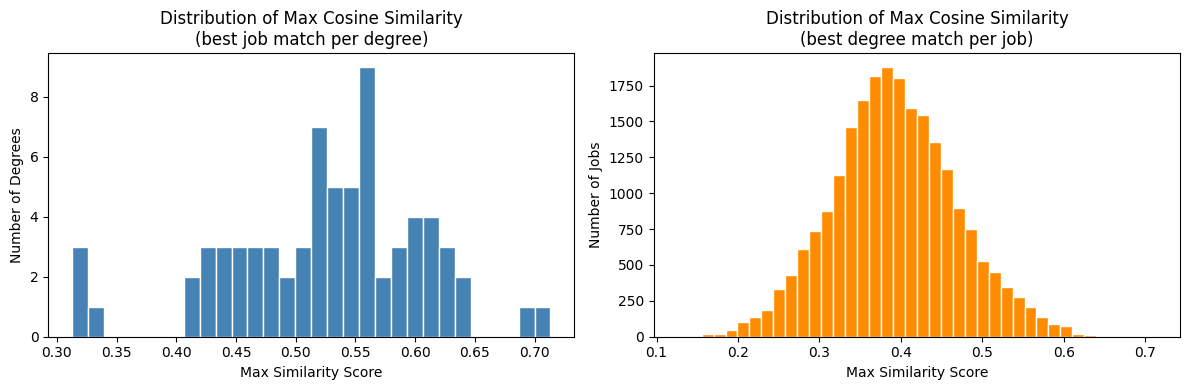

Degrees where best match > 0.5: 49 / 72


In [25]:
# Distribution of max similarity scores per degree (health check)
import matplotlib.pyplot as plt

max_sim_per_degree = sim_matrix.max(axis=1)
mean_sim_per_degree = sim_matrix.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(max_sim_per_degree, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Max Cosine Similarity\n(best job match per degree)')
axes[0].set_xlabel('Max Similarity Score')
axes[0].set_ylabel('Number of Degrees')

axes[1].hist(sim_matrix.max(axis=0), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Max Cosine Similarity\n(best degree match per job)')
axes[1].set_xlabel('Max Similarity Score')
axes[1].set_ylabel('Number of Jobs')

plt.tight_layout()
plt.savefig(CACHE_DIR / 'similarity_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Degrees where best match > 0.5: {(max_sim_per_degree > 0.5).sum()} / {len(degree_profiles)}')

---
## Section 5: Skill Overlap Score (Hybrid Alignment)

We complement semantic similarity with an explicit skill overlap signal. The structured `skills[]` field in job ads provides a clean skill vocabulary. We match this against degree profile text lexically.

In [26]:
# Build a global skill vocabulary from all job ads
all_skills = set()
for skill_list in jobs['skills']:
    if isinstance(skill_list, list):
        all_skills.update(s.lower().strip() for s in skill_list if s)

print(f'Unique skills in job ads: {len(all_skills):,}')

# Sort by length descending to match longer phrases first
skill_vocab = sorted(all_skills, key=len, reverse=True)
print('Sample skills:', skill_vocab[:20])

Unique skills in job ads: 0
Sample skills: []


In [27]:
def extract_skills_from_text(text: str, vocab: list[str]) -> set[str]:
    """Find which skills from vocab appear (case-insensitive, whole-word) in text."""
    text_lower = text.lower()
    found = set()
    for skill in vocab:
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found.add(skill)
    return found

def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

# Extract inferred skills from each degree profile
print('Extracting skills from degree profiles (may take a moment)...')
DEGREE_SKILLS_CACHE = CACHE_DIR / 'degree_skills.json'

if DEGREE_SKILLS_CACHE.exists():
    with open(DEGREE_SKILLS_CACHE) as f:
        degree_skills_raw = json.load(f)
    degree_skills = {k: set(v) for k, v in degree_skills_raw.items()}
    print('Loaded from cache.')
else:
    degree_skills = {}
    for _, row in tqdm(degree_profiles.iterrows(), total=len(degree_profiles), desc='Degree skill extraction'):
        degree_skills[row['degree_label']] = extract_skills_from_text(row['profile_text'], skill_vocab)
    with open(DEGREE_SKILLS_CACHE, 'w') as f:
        json.dump({k: list(v) for k, v in degree_skills.items()}, f)
    print('Cached degree skills.')

# Show skills found for CS
cs_label = degree_profiles[degree_profiles['department'].str.contains('Computer', case=False)]['degree_label']
if not cs_label.empty:
    lbl = cs_label.iloc[0]
    print(f'\nSkills found in {lbl}:')
    print(sorted(degree_skills[lbl])[:30])

Extracting skills from degree profiles (may take a moment)...
Loaded from cache.

Skills found in Electrical and Computer Engineering:
['3d', 'able', 'actuators', 'algebra', 'algorithms', 'analog', 'analog electronics', 'analysis', 'analytics', 'applications', 'architecture', 'architectures', 'art', 'artificial neural networks', 'asic', 'automation', 'autonomous', 'autonomous robot', 'basic', 'biomedical', 'biomedical engineering', 'case studies', 'classroom', 'cmos', 'collaboration', 'collaborative', 'communication', 'communication systems', 'communications', 'compensation']


In [28]:
# Skill overlap for each job's skill set against each degree's extracted skills
# Shape: (n_degrees × n_jobs)
SKILL_OVERLAP_CACHE = CACHE_DIR / 'skill_overlap_matrix.npy'

if SKILL_OVERLAP_CACHE.exists():
    print('Loading skill overlap matrix from cache...')
    skill_overlap_matrix = np.load(SKILL_OVERLAP_CACHE)
else:
    print('Computing skill overlap matrix...')
    n_deg = len(degree_profiles)
    n_job = len(jobs)
    skill_overlap_matrix = np.zeros((n_deg, n_job), dtype=np.float32)

    # Pre-convert job skills to list-of-sets for speed
    job_skill_sets = [
        set(s.lower().strip() for s in row if s)
        for row in jobs['skills'].tolist()
    ]

    for d_idx, (_, d_row) in enumerate(tqdm(degree_profiles.iterrows(), total=n_deg, desc='Skill overlap')):
        d_skills = degree_skills.get(d_row['degree_label'], set())
        if not d_skills:
            continue
        for j_idx, j_skills in enumerate(job_skill_sets):
            skill_overlap_matrix[d_idx, j_idx] = jaccard(d_skills, j_skills)

    np.save(SKILL_OVERLAP_CACHE, skill_overlap_matrix)
    print(f'Saved skill overlap matrix → {SKILL_OVERLAP_CACHE}')

print(f'Skill overlap matrix shape: {skill_overlap_matrix.shape}')
print(f'Non-zero entries: {(skill_overlap_matrix > 0).sum():,}')

Loading skill overlap matrix from cache...
Skill overlap matrix shape: (72, 22720)
Non-zero entries: 654,045


In [29]:
# Hybrid alignment score: weighted combination
ALPHA = 0.7  # weight for semantic similarity
BETA  = 0.3  # weight for skill overlap

hybrid_matrix = ALPHA * sim_matrix + BETA * skill_overlap_matrix
print(f'Hybrid score matrix shape: {hybrid_matrix.shape}')
print(f'Score range: [{hybrid_matrix.min():.4f}, {hybrid_matrix.max():.4f}]')

def top_k_jobs_hybrid(degree_idx: int, k: int = K) -> pd.DataFrame:
    """Return top-k jobs by hybrid alignment score for a given degree."""
    scores = hybrid_matrix[degree_idx]
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        'rank'        : range(1, k+1),
        'job_id'      : jobs.iloc[top_idx]['job_id'].values,
        'job_title'   : jobs.iloc[top_idx]['title'].values,
        'categories'  : jobs.iloc[top_idx]['categories_str'].values,
        'cosine_sim'  : sim_matrix[degree_idx, top_idx].round(4),
        'skill_overlap': skill_overlap_matrix[degree_idx, top_idx].round(4),
        'hybrid_score': scores[top_idx].round(4),
    })

Hybrid score matrix shape: (72, 22720)
Score range: [-0.1359, 0.5028]


In [30]:
# Compare baseline vs hybrid for Computer Science
if len(cs_label) > 0:
    cs_deg_idx = degree_profiles[degree_profiles['degree_label'] == cs_label.iloc[0]].index
    if len(cs_deg_idx) > 0:
        idx = degree_profiles.index.get_loc(cs_deg_idx[0])
        print(f'=== Hybrid Top-{K} for {cs_label.iloc[0]} ===')
        display(top_k_jobs_hybrid(idx, K))
    else:
        display(top_k_jobs_hybrid(0, K))
else:
    display(top_k_jobs_hybrid(0, K))

=== Hybrid Top-10 for Electrical and Computer Engineering ===


,rank,job_id,job_title,categories,cosine_sim,skill_overlap,hybrid_score
0,1,MCF-2026-0173729,Project Engineer(Electrical ),Building and Construction,0.5432,0.0094,0.3831
1,2,MCF-2026-0166830,Engineer (Electrical Project),Engineering,0.5345,0.0140,0.3784
2,3,MCF-2025-1627711,Project Engineer,Engineering,0.5330,0.0093,0.3759
3,4,MCF-2026-0174578,Project Engineer,Engineering,0.5339,0.0047,0.3751
4,5,MCF-2026-0158623,Project RC Engineer,Building and Construction,0.5267,0.0000,0.3687
5,6,MCF-2025-1726107,Project Engineer (Electrical),Building and Construction,0.5201,0.0094,0.3669
6,7,MCF-2026-0172520,Project Manager (M&E / 5 Days),"Building and Construction, Engineering",0.5182,0.0045,0.3641
7,8,MCF-2026-0165991,Project Manager,Consulting,0.5154,0.0093,0.3636
8,9,MCF-2026-0191392,Project Engineer,Information Technology,0.5154,0.0047,0.3622
9,10,MCF-2026-0182618,Project Engineer,Building and Construction,0.5110,0.0095,0.3606


---
## Section 6: Job Clustering (Scalability Layer)

Clustering job ads into role-level groups reduces sensitivity to firm-specific wording and provides MOE with a cleaner **degree ↔ job role category** view.

In [31]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer

N_CLUSTERS = 75  # adjust based on corpus size; 50–100 is a sensible range
CLUSTER_CACHE = CACHE_DIR / f'job_clusters_k{N_CLUSTERS}.npy'

if CLUSTER_CACHE.exists():
    print('Loading cluster labels from cache...')
    cluster_labels = np.load(CLUSTER_CACHE)
else:
    print(f'Clustering {len(jobs):,} jobs into {N_CLUSTERS} clusters...')
    t0 = time.time()
    kmeans = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        batch_size=2048,
        n_init=5,
        max_iter=300,
    )
    cluster_labels = kmeans.fit_predict(job_embeddings)
    np.save(CLUSTER_CACHE, cluster_labels)
    print(f'Done in {time.time()-t0:.1f}s — inertia: {kmeans.inertia_:.1f}')

jobs['cluster_id'] = cluster_labels
print('Cluster size distribution:')
print(jobs['cluster_id'].value_counts().describe().round(0))

Loading cluster labels from cache...
Cluster size distribution:
count      75.0
mean      303.0
std       140.0
min        72.0
25%       207.0
50%       291.0
75%       376.0
max      1060.0
Name: count, dtype: float64


In [32]:
# Label each cluster with its top TF-IDF terms and most common MCF category
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english', min_df=2)
tfidf.fit(jobs['description_clean'].tolist())
feature_names = np.array(tfidf.get_feature_names_out())

cluster_info = []
for c in range(N_CLUSTERS):
    mask = jobs['cluster_id'] == c
    cluster_jobs = jobs[mask]
    n = mask.sum()

    # Top TF-IDF terms
    vecs = tfidf.transform(cluster_jobs['description_clean'].tolist())
    mean_tfidf = np.asarray(vecs.mean(axis=0)).flatten()
    top_term_idx = mean_tfidf.argsort()[::-1][:8]
    top_terms = ', '.join(feature_names[top_term_idx])

    # Most common MCF category
    all_cats = [c for cats in cluster_jobs['categories'].tolist() for c in (cats if isinstance(cats, list) else [])]
    top_cat = pd.Series(all_cats).value_counts().index[0] if all_cats else 'Unknown'

    # Most common title words
    title_words = pd.Series(' '.join(cluster_jobs['title'].tolist()).lower().split()).value_counts()
    common_title = ', '.join(title_words.head(5).index.tolist())

    cluster_info.append({
        'cluster_id'   : c,
        'n_jobs'       : n,
        'top_category' : top_cat,
        'top_terms'    : top_terms,
        'common_titles': common_title,
    })

cluster_df = pd.DataFrame(cluster_info).sort_values('n_jobs', ascending=False)
print('Top 20 clusters by size:')
display(cluster_df.head(20))

Top 20 clusters by size:


,cluster_id,n_jobs,top_category,top_terms,common_titles
28,28,1060,Unknown,"ll, team, career, grow, face, growth, learn, m...","marketing, sales, brand, &, associate"
18,18,549,Unknown,"marketing, events, event, ll, team, learn, bra...","marketing, events, &, sales, event"
54,54,528,Unknown,"software, testing, test, design, technical, ex...","engineer, software, developer, -, senior"
7,7,509,Unknown,"security, network, cybersecurity, support, inf...","engineer, it, security, manager, support"
50,50,499,Unknown,"sales, business, marketing, market, client, bu...","executive, manager, business, development, sales"
47,47,452,Unknown,"food, kitchen, chef, cook, cooking, dishes, me...","chef, cook, assistant, sous, de"
43,43,451,Unknown,"financial, finance, accounting, compliance, ba...","finance, manager, -, officer, &"
49,49,442,Unknown,"sales, customer, marketing, customers, busines...","sales, manager, executive, marketing, &"
10,10,440,Unknown,"students, teaching, school, student, learning,...","teacher, |, -, &, /"
21,21,436,Unknown,"investment, financial, client, business, clien...","manager, -, &, investment, senior"


In [33]:
# Compute degree-to-cluster alignment matrix using cluster centroids
# Centroid = mean of unit-norm embeddings → re-normalise for cosine sim

cluster_centroids = np.zeros((N_CLUSTERS, job_embeddings.shape[1]), dtype=np.float32)
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    if mask.sum() > 0:
        centroid = job_embeddings[mask].mean(axis=0)
        norm = np.linalg.norm(centroid)
        cluster_centroids[c] = centroid / norm if norm > 0 else centroid

# degree-cluster similarity: (n_degrees × n_clusters)
degree_cluster_sim = degree_embeddings @ cluster_centroids.T
print(f'Degree-cluster similarity matrix: {degree_cluster_sim.shape}')

Degree-cluster similarity matrix: (72, 75)


In [34]:
# Build a labelled degree-cluster alignment table
cluster_label_map = dict(zip(cluster_df['cluster_id'], cluster_df['top_category']))

alignment_rows = []
for d_idx, d_row in degree_profiles.iterrows():
    d_pos = degree_profiles.index.get_loc(d_idx)
    scores = degree_cluster_sim[d_pos]
    top_clusters = np.argsort(scores)[::-1][:5]
    for rank, c_id in enumerate(top_clusters, 1):
        alignment_rows.append({
            'degree'        : d_row['degree_label'],
            'faculty'       : d_row['faculty'],
            'rank'          : rank,
            'cluster_id'    : int(c_id),
            'cluster_label' : cluster_label_map.get(int(c_id), f'Cluster {c_id}'),
            'cluster_terms' : cluster_df[cluster_df['cluster_id'] == c_id]['top_terms'].values[0] if len(cluster_df[cluster_df['cluster_id'] == c_id]) > 0 else '',
            'sim_score'     : round(float(scores[c_id]), 4),
        })

alignment_table = pd.DataFrame(alignment_rows)
alignment_table.to_csv(CACHE_DIR / 'degree_cluster_alignment.csv', index=False)
print('Sample: top-3 cluster matches per degree (first 5 degrees)')
display(alignment_table[alignment_table['rank'] <= 3].head(15))

Sample: top-3 cluster matches per degree (first 5 degrees)


,degree,faculty,rank,cluster_id,cluster_label,cluster_terms,sim_score
0,Centre for Language Studies,Arts and Social Science,1,10,Unknown,"students, teaching, school, student, learning,...",0.3104
1,Centre for Language Studies,Arts and Social Science,2,65,Unknown,"chinese, teaching, children, secondary levels,...",0.2879
2,Centre for Language Studies,Arts and Social Science,3,60,Unknown,"data, business, risk, analysis, experience, su...",0.2115
5,Chinese Studies,Arts and Social Science,1,65,Unknown,"chinese, teaching, children, secondary levels,...",0.4463
6,Chinese Studies,Arts and Social Science,2,10,Unknown,"students, teaching, school, student, learning,...",0.2538
7,Chinese Studies,Arts and Social Science,3,51,Unknown,"legal, corporate, secretarial, law, corporate ...",0.2245
10,Communications and New Media,Arts and Social Science,1,24,Unknown,"marketing, content, media, social, social medi...",0.4184
11,Communications and New Media,Arts and Social Science,2,44,Unknown,"project, site, works, engineering, electrical,...",0.3879
12,Communications and New Media,Arts and Social Science,3,41,Unknown,"recruit expert, expert com, construction, proj...",0.3858
15,Economics,Arts and Social Science,1,44,Unknown,"project, site, works, engineering, electrical,...",0.3924


---
## Section 7: Evaluation Framework

We construct a stratified golden test set of degree-job pairs, annotate them with human judgement labels, then compute retrieval quality metrics.

### 7a - Golden Test Set Construction

In [35]:
GOLDEN_SET_PATH = EVAL_DIR / 'golden_set.csv'

def sample_golden_pairs(
    degrees: pd.DataFrame,
    jobs_df: pd.DataFrame,
    sim_mat: np.ndarray,
    n_per_stratum: int = 15,
    k_top: int = 10,
) -> pd.DataFrame:
    """
    Sample degree-job pairs across three strata:
      - High similarity  (top-k retrieved): likely Relevant
      - Mid  similarity  (rank k+1..5k): likely Somewhat Relevant
      - Low  similarity  (random from bottom half): likely Not Relevant
    """
    rng = np.random.default_rng(42)
    n_deg = len(degrees)
    n_job = len(jobs_df)
    pairs = []

    # Randomly select a subset of degrees to annotate
    selected_deg_idx = rng.choice(n_deg, size=min(10, n_deg), replace=False)

    for d_idx in selected_deg_idx:
        degree_label = degrees.iloc[d_idx]['degree_label']
        scores = sim_mat[d_idx]
        rank_order = np.argsort(scores)[::-1]

        # Stratum 1: top-k (expected high relevance)
        high = rank_order[:k_top]
        for j_idx in rng.choice(high, size=min(5, len(high)), replace=False):
            pairs.append({'degree': degree_label, 'stratum': 'high', 'job_idx': int(j_idx), 'system_score': round(float(scores[j_idx]), 4)})

        # Stratum 2: mid-range (rank k+1 to 5k)
        mid = rank_order[k_top: k_top*5]
        for j_idx in rng.choice(mid, size=min(5, len(mid)), replace=False):
            pairs.append({'degree': degree_label, 'stratum': 'mid', 'job_idx': int(j_idx), 'system_score': round(float(scores[j_idx]), 4)})

        # Stratum 3: bottom half (expected low relevance)
        low = rank_order[n_job//2:]
        for j_idx in rng.choice(low, size=min(5, len(low)), replace=False):
            pairs.append({'degree': degree_label, 'stratum': 'low', 'job_idx': int(j_idx), 'system_score': round(float(scores[j_idx]), 4)})

    result = pd.DataFrame(pairs)
    result['job_id']    = result['job_idx'].apply(lambda i: jobs_df.iloc[i]['job_id'])
    result['job_title'] = result['job_idx'].apply(lambda i: jobs_df.iloc[i]['title'])
    result['job_categories'] = result['job_idx'].apply(lambda i: jobs_df.iloc[i]['categories_str'])
    result['human_label'] = ''   # fill in: 2=Relevant, 1=Somewhat Relevant, 0=Not Relevant
    result['annotator_notes'] = ''
    return result[['degree','stratum','job_id','job_title','job_categories','system_score','human_label','annotator_notes']]


if not GOLDEN_SET_PATH.exists():
    golden_df = sample_golden_pairs(degree_profiles, jobs, hybrid_matrix)
    golden_df.to_csv(GOLDEN_SET_PATH, index=False)
    print(f'Golden test set scaffold saved → {GOLDEN_SET_PATH}')
    print(f'Total pairs: {len(golden_df)}  (please fill in human_label column offline)')
else:
    golden_df = pd.read_csv(GOLDEN_SET_PATH)
    print(f'Loaded existing golden set: {len(golden_df)} pairs')

display(golden_df.head(10))

Loaded existing golden set: 150 pairs


,degree,stratum,job_id,job_title,job_categories,system_score,human_label,annotator_notes
0,Microbiology and Immunology,high,MCF-2026-0160236,Microbiology (MNC) #HMS,Sciences / Laboratory / R&D,0.3654,NaN,NaN
1,Microbiology and Immunology,high,MCF-2026-0190584,"Contract Associate Scientist, Cell Culture (Bi...","Environment / Health, Healthcare / Pharmaceuti...",0.3379,NaN,NaN
2,Microbiology and Immunology,high,MCF-2025-1991434,Dr Zhang Dan Group: Assistant Research Officer...,Sciences / Laboratory / R&D,0.3629,NaN,NaN
3,Microbiology and Immunology,high,MCF-2026-0191216,Associate Scientist – Cell Culture (1 yr contr...,"Healthcare / Pharmaceutical, Sciences / Labora...",0.3422,NaN,NaN
4,Microbiology and Immunology,high,MCF-2026-0191331,(Principal) Senior Medical Laboratory Scientis...,"Environment / Health, Healthcare / Pharmaceutical",0.3714,NaN,NaN
5,Microbiology and Immunology,mid,MCF-2026-0159351,Research Fellow (Cellular Agriculture),Sciences / Laboratory / R&D,0.3239,NaN,NaN
6,Microbiology and Immunology,mid,MCF-2026-0180647,"Scientist II (Molecular Diagnostics), DxD Hub",Sciences / Laboratory / R&D,0.2914,NaN,NaN
7,Microbiology and Immunology,mid,MCF-2026-0177178,Senior Scientific Support Specialist (Microbio...,"Environment / Health, Healthcare / Pharmaceuti...",0.2895,NaN,NaN
8,Microbiology and Immunology,mid,MCF-2026-0157324,"Junior Scientist (Discovery Chemistry), EDDC",Sciences / Laboratory / R&D,0.3071,NaN,NaN
9,Microbiology and Immunology,mid,MCF-2026-0180719,"Scientist II (Molecular Diagnostics), DxD Hub",Sciences / Laboratory / R&D,0.2903,NaN,NaN


### 7b - Evaluation Metrics

Run this cell after filling in the `human_label` column in `evaluation/golden_set.csv`.

In [36]:
from scipy.stats import spearmanr

def precision_at_k(relevant_flags: list[int], k: int) -> float:
    """Fraction of top-k retrieved items that are relevant (label >= 1)."""
    top_k = relevant_flags[:k]
    return sum(1 for r in top_k if r >= 1) / k

def ndcg_at_k(labels: list[int], k: int) -> float:
    """Normalised Discounted Cumulative Gain at rank k."""
    def dcg(l, k):
        return sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(l[:k]))
    ideal = sorted(labels, reverse=True)
    idcg = dcg(ideal, k)
    return dcg(labels, k) / idcg if idcg > 0 else 0.0

def top_k_hit_rate(relevant_flags: list[int], k: int) -> int:
    """1 if at least one Relevant (label == 2) item appears in top-k, else 0."""
    return int(any(r == 2 for r in relevant_flags[:k]))

def evaluate_system(golden: pd.DataFrame, sim_mat: np.ndarray, degrees: pd.DataFrame, jobs_df: pd.DataFrame, k: int = 10):
    """
    For each degree in the golden set, rank the annotated jobs by system score,
    then compute Precision@K, NDCG@K, and Top-K Hit Rate.
    Also compute Spearman ρ for human-model agreement.
    """
    annotated = golden[golden['human_label'].apply(lambda x: str(x).strip()).isin(['0','1','2'])].copy()
    annotated['human_label'] = annotated['human_label'].astype(int)

    if annotated.empty:
        print('No annotated pairs found. Please fill in human_label column first.')
        return None

    results = []
    for degree_label, grp in annotated.groupby('degree'):
        grp_sorted = grp.sort_values('system_score', ascending=False)
        labels_ranked = grp_sorted['human_label'].tolist()

        p_at_k  = precision_at_k(labels_ranked, min(k, len(labels_ranked)))
        ndcg    = ndcg_at_k(labels_ranked, min(k, len(labels_ranked)))
        hit     = top_k_hit_rate(labels_ranked, min(k, len(labels_ranked)))

        results.append({'degree': degree_label, f'Precision@{k}': p_at_k, f'NDCG@{k}': ndcg, f'HitRate@{k}': hit})

    metrics_df = pd.DataFrame(results)

    # Human-model agreement (Spearman ρ) across all annotated pairs
    rho, pval = spearmanr(annotated['system_score'], annotated['human_label'])

    print('=== Evaluation Results ===')
    print(f'  Annotated pairs      : {len(annotated)}')
    print(f'  Degrees evaluated    : {annotated["degree"].nunique()}')
    print(f'  Spearman ρ (human-model agreement): {rho:.4f}  (p={pval:.4f})')
    print()
    print(metrics_df.describe().round(3))
    return metrics_df, rho

eval_results = evaluate_system(golden_df, hybrid_matrix, degree_profiles, jobs)

No annotated pairs found. Please fill in human_label column first.


### 7c - Coverage Report

In [37]:
print('=' * 50)
print('  FRAMEWORK COVERAGE REPORT')
print('=' * 50)

# Job ad coverage
print('\n[Job Ads]')
print(f'  Files found           : {len(job_files):>8,}')
print(f'  Successfully parsed   : {len(jobs_raw):>8,}  ({len(jobs_raw)/len(job_files)*100:.1f}%)')
print(f'  Usable (with text)    : {len(jobs):>8,}  ({len(jobs)/len(job_files)*100:.1f}%)')
print(f'  With skill tags       : {jobs["skills"].apply(len).gt(0).sum():>8,}  ({jobs["skills"].apply(len).gt(0).mean()*100:.1f}%)')

# Module coverage
print('\n[NUS Modules]')
print(f'  Total rows in CSV     : {len(modules_raw):>8,}')
print(f'  With usable desc      : {len(modules_clean):>8,}  ({len(modules_clean)/len(modules_raw)*100:.1f}%)')
print(f'  Undergrad (1–4xxx)    : {modules_clean["is_undergrad"].sum():>8,}  ({modules_clean["is_undergrad"].mean()*100:.1f}%)')

# Degree profile coverage
print('\n[Degree Profiles]')
total_depts = modules_clean['department'].nunique()
profiled    = len(degree_profiles)
suf         = (dept_coverage['n_modules'] >= 5).sum()
print(f'  Unique departments    : {total_depts:>8,}')
print(f'  Departments profiled  : {profiled:>8,}  ({profiled/total_depts*100:.1f}%)')
print(f'  With ≥5 modules       : {suf:>8,}  ({suf/total_depts*100:.1f}%)')

print('\n[Alignment Coverage]')
print(f'  Degrees × Jobs pairs  : {len(degree_profiles):,} × {len(jobs):,} = {len(degree_profiles)*len(jobs):,}')
print(f'  Pairs computed        : 100.0% (full matrix)')
print('=' * 50)

  FRAMEWORK COVERAGE REPORT

[Job Ads]
  Files found           :   22,720
  Successfully parsed   :   22,720  (100.0%)
  Usable (with text)    :   22,720  (100.0%)
  With skill tags       :   22,720  (100.0%)

[NUS Modules]
  Total rows in CSV     :    7,015
  With usable desc      :    6,730  (95.9%)
  Undergrad (1–4xxx)    :    4,032  (59.9%)

[Degree Profiles]
  Unique departments    :       86
  Departments profiled  :       72  (83.7%)
  With ≥5 modules       :       71  (82.6%)

[Alignment Coverage]
  Degrees × Jobs pairs  : 72 × 22,720 = 1,635,840
  Pairs computed        : 100.0% (full matrix)


---
## Section 8: Results Summary & Interpretation

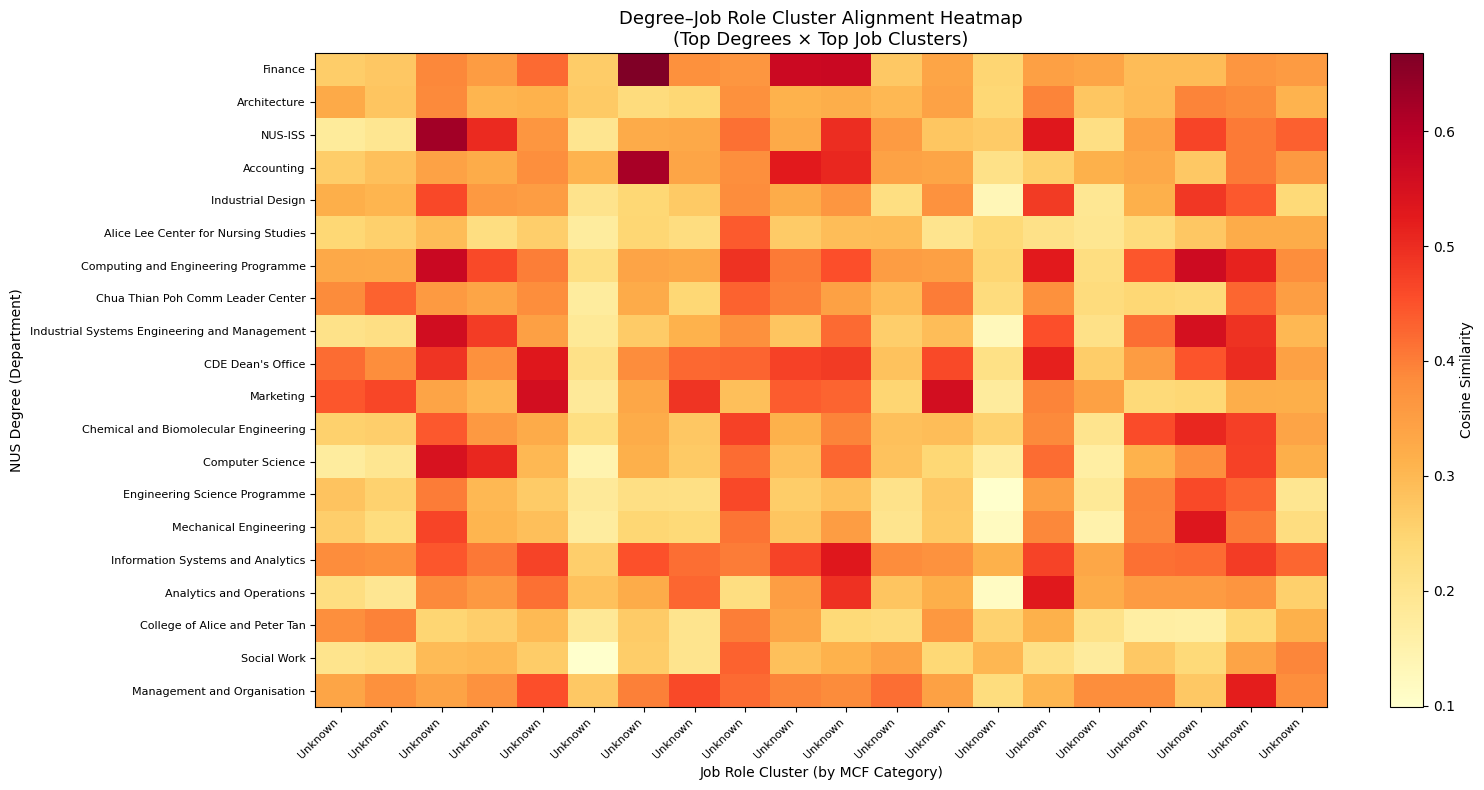

In [38]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Select top N degrees and top M clusters for the heatmap
TOP_DEG = 20
TOP_CLU = 20

# Pick the most "active" degrees (those with highest max cluster alignment)
max_cluster_score = degree_cluster_sim.max(axis=1)
top_deg_idx = np.argsort(max_cluster_score)[::-1][:TOP_DEG]
top_deg_labels = degree_profiles.iloc[top_deg_idx]['degree_label'].tolist()

# Pick the top clusters by size
top_clu_ids = cluster_df.head(TOP_CLU)['cluster_id'].tolist()
top_clu_labels = cluster_df.head(TOP_CLU)['top_category'].tolist()

heatmap_data = degree_cluster_sim[np.ix_(top_deg_idx, top_clu_ids)]

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Cosine Similarity')

ax.set_xticks(range(TOP_CLU))
ax.set_xticklabels(top_clu_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(TOP_DEG))
ax.set_yticklabels(top_deg_labels, fontsize=8)
ax.set_title('Degree–Job Role Cluster Alignment Heatmap\n(Top Degrees × Top Job Clusters)', fontsize=13)
ax.set_xlabel('Job Role Cluster (by MCF Category)', fontsize=10)
ax.set_ylabel('NUS Degree (Department)', fontsize=10)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'alignment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Top-5 matching job roles (by hybrid score) per NUS degree — summary table
TOP_JOBS_PER_DEGREE = 5

summary_rows = []
for d_pos in range(len(degree_profiles)):
    scores = hybrid_matrix[d_pos]
    top_idx = np.argsort(scores)[::-1][:TOP_JOBS_PER_DEGREE]
    d_label = degree_profiles.iloc[d_pos]['degree_label']
    d_faculty = degree_profiles.iloc[d_pos]['faculty']
    for rank, j_idx in enumerate(top_idx, 1):
        summary_rows.append({
            'faculty'       : d_faculty,
            'degree'        : d_label,
            'rank'          : rank,
            'job_title'     : jobs.iloc[j_idx]['title'],
            'job_categories': jobs.iloc[j_idx]['categories_str'],
            'hybrid_score'  : round(float(scores[j_idx]), 4),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(CACHE_DIR / 'degree_job_alignment_summary.csv', index=False)
print(f'Summary table saved → {CACHE_DIR}/degree_job_alignment_summary.csv')
print(f'Total rows: {len(summary_df):,}')
display(summary_df.head(20))

Summary table saved → /Users/marcusyeo/Github/DSA4264-Text-Group-3/notebooks/cache/degree_job_alignment_summary.csv
Total rows: 360


,faculty,degree,rank,job_title,job_categories,hybrid_score
0,Arts and Social Science,Centre for Language Studies,1,Freelance Arabic Language Teacher,"Education and Training, Professional Services,...",0.3934
1,Arts and Social Science,Centre for Language Studies,2,Language Instructor (Extracurriculum),Education and Training,0.3132
2,Arts and Social Science,Centre for Language Studies,3,Freelance Malay Language Teacher,"Education and Training, Professional Services,...",0.3075
3,Arts and Social Science,Centre for Language Studies,4,Freelance Tagalog Language Teacher,"Education and Training, Professional Services,...",0.3064
4,Arts and Social Science,Centre for Language Studies,5,Freelance Hokkien Language Teacher,"Education and Training, Professional Services,...",0.3018
5,Arts and Social Science,Chinese Studies,1,Part Time O level Chinese Teacher | Town,Education and Training,0.3231
6,Arts and Social Science,Chinese Studies,2,Primary Chinese Language Teacher #77203,"Education and Training, Others",0.3223
7,Arts and Social Science,Chinese Studies,3,Chinese Language Teacher (Secondary School),Education and Training,0.3208
8,Arts and Social Science,Chinese Studies,4,Assistant Curator,Events / Promotions,0.3195
9,Arts and Social Science,Chinese Studies,5,华文幼教老师 L2 Chinese Teacher,Education and Training,0.3118


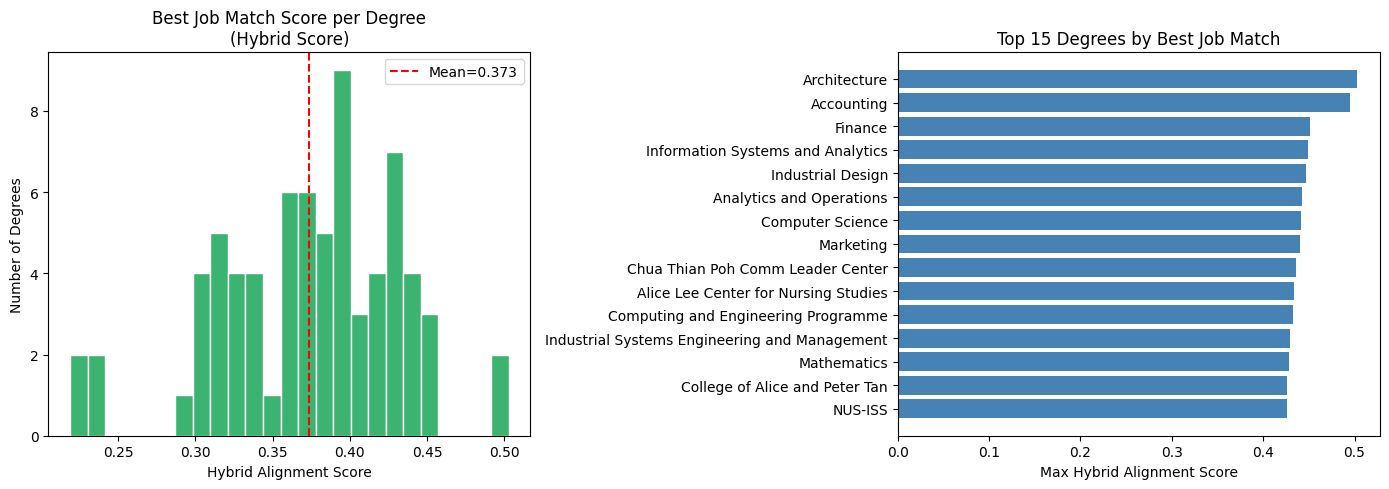

In [42]:
# Degree-level alignment score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of top-1 hybrid score per degree
top1_scores = hybrid_matrix.max(axis=1)
axes[0].hist(top1_scores, bins=25, color='mediumseagreen', edgecolor='white')
axes[0].axvline(top1_scores.mean(), color='red', linestyle='--', label=f'Mean={top1_scores.mean():.3f}')
axes[0].set_title('Best Job Match Score per Degree\n(Hybrid Score)')
axes[0].set_xlabel('Hybrid Alignment Score')
axes[0].set_ylabel('Number of Degrees')
axes[0].legend()

# Top degrees by max alignment
degree_profiles['max_hybrid_score'] = top1_scores
top_aligned = degree_profiles.nlargest(15, 'max_hybrid_score')[['degree_label','faculty','max_hybrid_score']]
axes[1].barh(top_aligned['degree_label'], top_aligned['max_hybrid_score'], color='steelblue')
axes[1].set_xlabel('Max Hybrid Alignment Score')
axes[1].set_title('Top 15 Degrees by Best Job Match')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(CACHE_DIR / 'degree_alignment_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Final framework summary
print('=' * 60)
print('  NUS CURRICULUM-JOB ALIGNMENT FRAMEWORK — SUMMARY')
print('=' * 60)
print(f'\nModel      : {MODEL_NAME}')
print(f'Hybrid α   : {ALPHA} (semantic)  β: {BETA} (skill overlap)')
print(f'Job clusters: {N_CLUSTERS}')

print(f'''
Scale
  Job ads processed       : {len(jobs):,}
  Degree profiles         : {len(degree_profiles)}
  Degree-job pairs scored : {len(degree_profiles) * len(jobs):,}

Key Outputs (saved to notebooks/cache/)
  degree_job_alignment_summary.csv  — top-5 jobs per degree
  degree_cluster_alignment.csv      — top-5 job clusters per degree
  alignment_heatmap.png             — degree × job cluster heatmap
  degree_alignment_scores.png       — score distribution

Golden Set (to annotate)
  notebooks/evaluation/golden_set.csv
  Fill in human_label (2=Relevant, 1=Somewhat, 0=Not Relevant)
  then re-run Section 7b for Precision@K / NDCG@K / Spearman ρ
''')
print('=' * 60)

  NUS CURRICULUM-JOB ALIGNMENT FRAMEWORK — SUMMARY

Model      : all-MiniLM-L6-v2
Hybrid α   : 0.7 (semantic)  β: 0.3 (skill overlap)
Job clusters: 75

Scale
  Job ads processed       : 22,720
  Degree profiles         : 72
  Degree-job pairs scored : 1,635,840

Key Outputs (saved to notebooks/cache/)
  degree_job_alignment_summary.csv  — top-5 jobs per degree
  degree_cluster_alignment.csv      — top-5 job clusters per degree
  alignment_heatmap.png             — degree × job cluster heatmap
  degree_alignment_scores.png       — score distribution

Golden Set (to annotate)
  notebooks/evaluation/golden_set.csv
  Fill in human_label (2=Relevant, 1=Somewhat, 0=Not Relevant)
  then re-run Section 7b for Precision@K / NDCG@K / Spearman ρ

